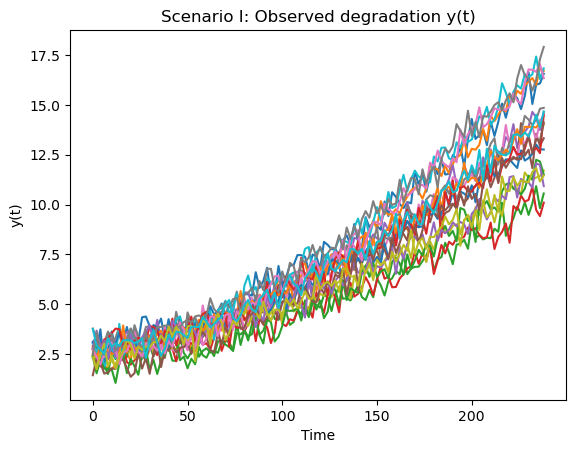

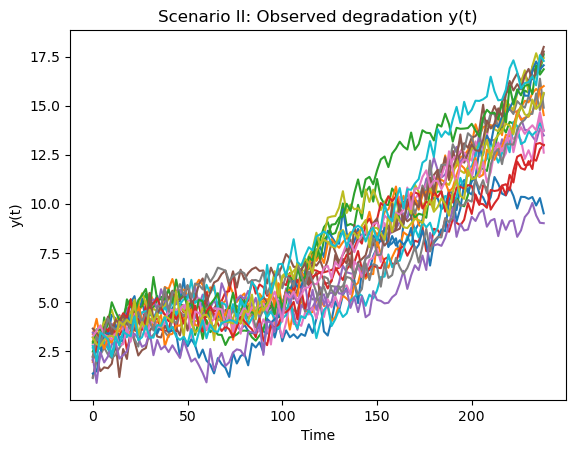

Done.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

np.random.seed(123)

L = 120                 
delta_t = 2.0           
t_grid = np.arange(L) * delta_t

lam, rho = 0.001, 1.05  
gamma, beta = 0.2, 0.5 
sigma_eps = np.sqrt(0.2)

mu_b = np.array([2.5, 0.01, 0.01])
Sigma_b = np.array([
    [0.2, -4e-4, 7e-5],
    [-4e-4, 3e-6, 1e-7],
    [7e-5, 1e-7, 3e-6]
])


def generate_fk_m(t, b, scenario):
    base = b[0] + b[1] * t**1.2 + b[2] * t**1.7
    if scenario == "I": 
        z = 0.0
    elif scenario == "II": 
        c = np.random.uniform(0.99, 1.01)
        d = np.random.uniform(0.18, 0.22)
        z = c * np.sin(d * t)
    else:
        raise ValueError("Scenario must be 'I' or 'II'")
    return base + z

def generate_yk_m(f_t):
    eps = np.random.normal(0, sigma_eps, size=len(f_t))
    return f_t + eps


def baseline_hazard(t):
    return lam * rho * t**(rho - 1)

def cumulative_hazard(t, w, f_t):
    h_t = baseline_hazard(t) * np.exp(gamma * w + beta * f_t)
    return np.cumsum(h_t) * delta_t

def generate_failure_time(t, w, f_t):
    H_t = cumulative_hazard(t, w, f_t)
    F_t = 1.0 - np.exp(-H_t)
    u = np.random.uniform()
    if u > F_t[-1]:
        return t[-1], 0
    invF = interp1d(F_t, t, kind="linear", fill_value="extrapolate")
    return float(invF(u)), 1

def simulate_full_curves(n_units=5, scenario="I"):
    """
    Generate full degradation curves without truncation by failure.
    """
    curves = []
    for _ in range(n_units):
        b = np.random.multivariate_normal(mu_b, Sigma_b)
        f_t = generate_fk_m(t_grid, b, scenario)
        y_t = generate_yk_m(f_t)
        curves.append({
            "t": t_grid,
            "f": f_t,
            "y": y_t
        })
    return curves


curves_I = simulate_full_curves(n_units=20, scenario="I")
curves_II = simulate_full_curves(n_units=20, scenario="II")


plt.figure()
for c in curves_I:
    plt.plot(c["t"], c["y"])
plt.title("Scenario I: Observed degradation y(t)")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.show()


plt.figure()
for c in curves_II:
    plt.plot(c["t"], c["y"])
plt.title("Scenario II: Observed degradation y(t)")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.show()
